# Part 0: Imports, environment and reproducibility

Importing all the libraries I need for data handling, plotting, ML models (both sklearn and PyTorch) and also setting up random seeds and device configuration so my experiments are reproducible and can optionally use GPU if available

In [1]:

import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")
np.random.seed(42)

from pandas.tseries.holiday import USFederalHolidayCalendar as Calendar
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

plt.rcParams["figure.figsize"] = (12, 4)

torch.manual_seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cpu


# Part 1: Loading PJM West hourly dataset

In this part I'm loading the PJM West hourly electricity usage data from a CSV file into a pandas DataFrame and doing some basic renaming


In [2]:
CSV_NAME = "PJMW_hourly.csv"
df = pd.read_csv(CSV_NAME)
df = df.rename(columns={"Datetime": "DATE_TIME", "PJMW_MW": "USAGE"})

print(df.head())  # Checking first few rows to confirm that the data was loaded and renamed correctly.

             DATE_TIME   USAGE
0  2002-12-31 01:00:00  5077.0
1  2002-12-31 02:00:00  4939.0
2  2002-12-31 03:00:00  4885.0
3  2002-12-31 04:00:00  4857.0
4  2002-12-31 05:00:00  4930.0


# Part 2: Basic cleaning and datetime conversion

In this part, I'm cleaning the raw data by converting types, ensuring numeric values, removing invalid rows and sorting by time so that the time series is well-structured and ready for feature engineering


In [3]:
df["DATE_TIME"] = pd.to_datetime(df["DATE_TIME"], errors="coerce")
# Converting the DATE_TIME column to actual datetime objects and coercing bad values to NaT.

# Ensuring USAGE is numeric
df["USAGE"] = pd.to_numeric(df["USAGE"], errors="coerce")

df = df.dropna(subset=["DATE_TIME", "USAGE"]).sort_values("DATE_TIME").reset_index(drop=True)
# Here I'm removing any rows where DATE_TIME or USAGE is invalid,
# then sorting by DATE_TIME to maintain chronological order and resetting the index to keep the DataFrame tidy.

print("After cleaning:", df.shape)
print(df[["DATE_TIME", "USAGE"]].head())

After cleaning: (143206, 2)
            DATE_TIME   USAGE
0 2002-04-01 01:00:00  4374.0
1 2002-04-01 02:00:00  4306.0
2 2002-04-01 03:00:00  4322.0
3 2002-04-01 04:00:00  4359.0
4 2002-04-01 05:00:00  4436.0


# Part 3: EDA plots

In this, I'm doing some exploratory data analysis (EDA) by plotting the raw time series and the distribution of the usage. This helps me visually understand trends, seasonality and overall scale


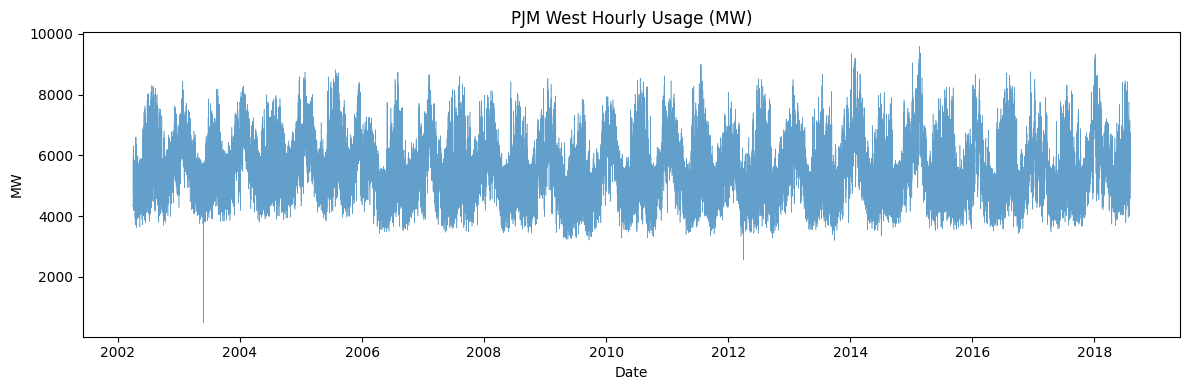

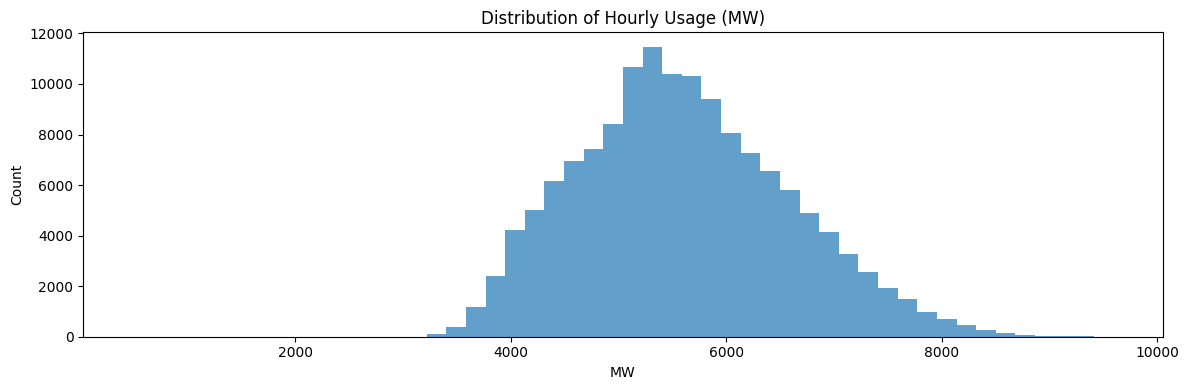

In [4]:
# Time series plot
plt.figure()
plt.plot(df["DATE_TIME"], df["USAGE"], linewidth=0.4, alpha=0.7)  # I'm plotting usage over time to see global trends and variability
plt.title("PJM West Hourly Usage (MW)")
plt.xlabel("Date")
plt.ylabel("MW")
plt.tight_layout()
plt.show()

# Histogram
plt.figure()
plt.hist(df["USAGE"], bins=50, alpha=0.7)  # plotting a histogram of usage to examine its distribution
plt.title("Distribution of Hourly Usage (MW)")
plt.xlabel("MW")
plt.ylabel("Count")
plt.tight_layout()
plt.show()


# Part 4: Calendar-based features(weekend and holidays)

In this part, I'm engineering simple calendar-based features: whether a timestamp falls on a weekend and whether it's a US federal holiday. These features can help models capture patterns tied to human activity and schedules

In [5]:
# Creating a binary feature indicating weekend vs weekday
# Only Sunday = 1, others = 0
df["DAY_TYPE"] = df["DATE_TIME"].dt.dayofweek.apply(lambda x: 1 if x > 5 else 0)

# U.S. federal holidays
cal = Calendar()
holidays = cal.holidays(start=df["DATE_TIME"].min(), end=df["DATE_TIME"].max())

df["IS_HOLIDAY"] = df["DATE_TIME"].dt.normalize().isin(holidays).astype(int)
# I'm normalizing timestamps to midnight and checking if each date is in the holiday list and then I convert that boolean flag to 0/1


# Part 5: Lag features (t_1 ... t_5)

I'm creating autoregressive lag features from the USAGE series. These features let the models see recent past values (last few hours) to improve short-term forecasting performance

In [6]:
for k in range(1, 6):
    df[f"t_{k}"] = df["USAGE"].shift(k)
    # For each lag k from 1 to 5 I'm shifting the USAGE series by k steps
    # and storing it as t_k, so the model can use previous k hours as inputs

df.fillna(0.0, inplace=True)
# I'm filling the NaN values created by lagging (at the start of the series)
# with 0.0 so my models don't break due to missing values.

# Part 6: Feature and target definition

In this part, I'm defining which columns are my input features and which column is the prediction target. Then I convert them to NumPy arrays with a consistent float32 dtype for later use

In [7]:
feature_cols = ["DAY_TYPE", "IS_HOLIDAY", "t_1", "t_2", "t_3", "t_4", "t_5"]
target_col = "USAGE"

X_full = df[feature_cols].values.astype("float32")
y_full = df[target_col].values.astype("float32")

print("Feature shape:", X_full.shape, " Target shape:", y_full.shape)

Feature shape: (143206, 7)  Target shape: (143206,)


# Part 7: EDA on features

In this, I'm exploring how usage behaves across different
time-based factors such as hour of day, day of week and holiday vs non-holiday. This helps me understand patterns that my models might exploit

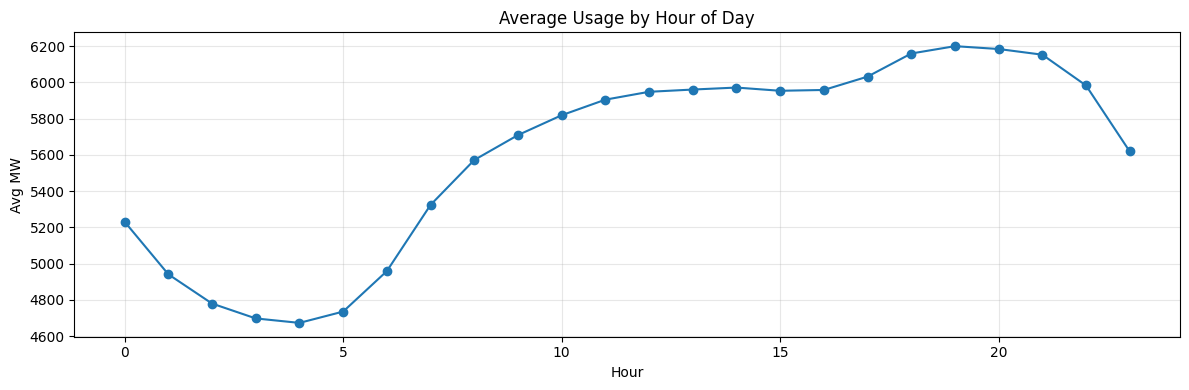

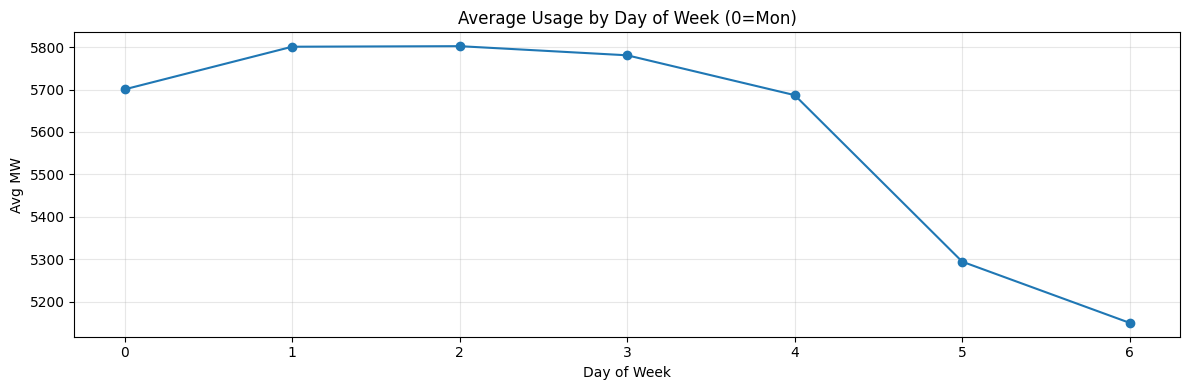

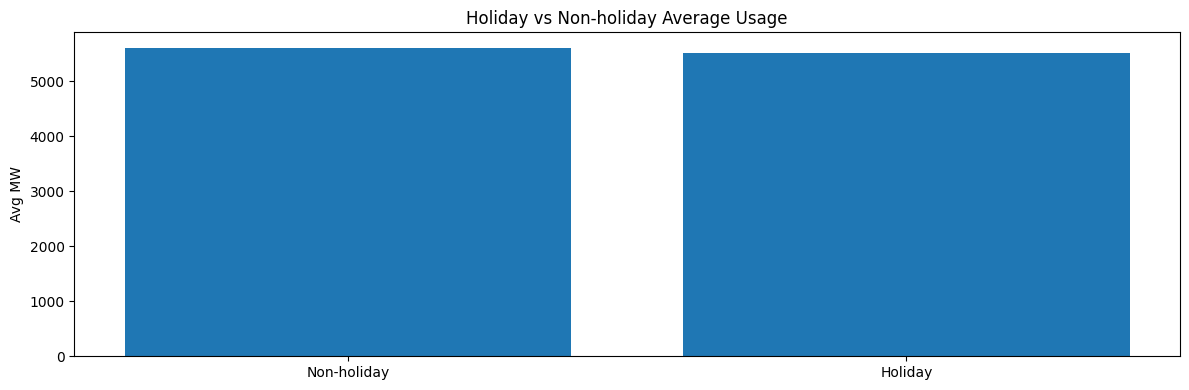

In [8]:
# Average usage by hour of day
hourly_avg = df.groupby(df["DATE_TIME"].dt.hour)["USAGE"].mean()

plt.figure()
plt.plot(hourly_avg.index, hourly_avg.values, marker="o")
plt.title("Average Usage by Hour of Day")
plt.xlabel("Hour")
plt.ylabel("Avg MW")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Average usage by day of week
dow_avg = df.groupby(df["DATE_TIME"].dt.dayofweek)["USAGE"].mean()

plt.figure()
plt.plot(dow_avg.index, dow_avg.values, marker="o")
plt.title("Average Usage by Day of Week (0=Mon)")
plt.xlabel("Day of Week")
plt.ylabel("Avg MW")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Holidays vs non-holidays
holiday_avg = df.groupby("IS_HOLIDAY")["USAGE"].mean()

plt.figure()
plt.bar(["Non-holiday", "Holiday"], holiday_avg.values)
plt.title("Holiday vs Non-holiday Average Usage")
plt.ylabel("Avg MW")
plt.tight_layout()
plt.show()

# Part 8: Time-based train, val and test split

In this, I'm splitting the time series into training, validation and test sets based on calendar dates. This preserves temporal order and mimics a real forecasting scenario

Train range: 2002-04-01 01:00:00 → 2016-12-31 23:00:00
Val range  : 2017-01-01 00:00:00 → 2017-06-30 23:00:00
Test range : 2017-07-01 00:00:00 → 2018-08-03 00:00:00


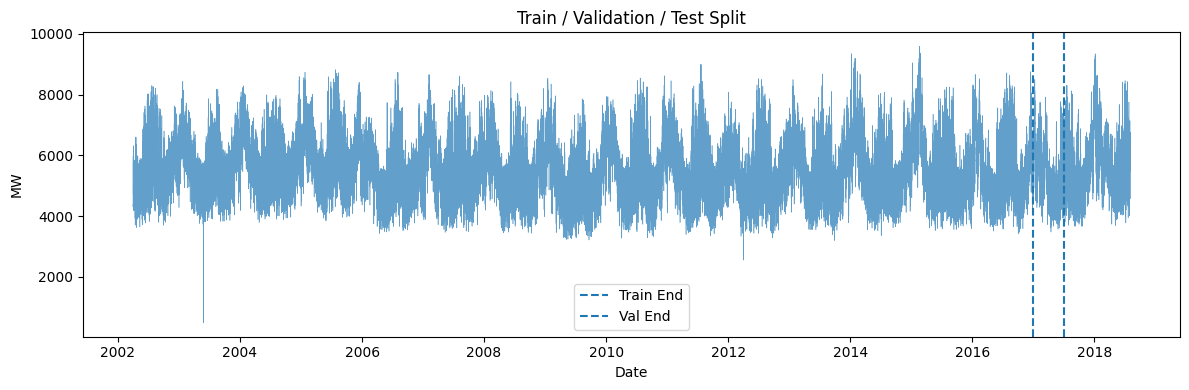

Shapes → Train: (129310, 7) Val: (4343, 7) Test: (9553, 7)
Raw lengths → train: 129310 val: 4343 test: 9553


In [9]:

TRAIN_END = pd.to_datetime("2017-01-01")   # training data ends before this date
VAL_END   = pd.to_datetime("2017-07-01")   # validation data ends before this date
TEST_BEG  = pd.to_datetime("2017-07-01")   # test data starts from here onward

mask_train = df["DATE_TIME"] < TRAIN_END
mask_val   = (df["DATE_TIME"] >= TRAIN_END) & (df["DATE_TIME"] < VAL_END)
mask_test  = df["DATE_TIME"] >= TEST_BEG
# I'm creating boolean masks corresponding to train, val and test ranges
# so I can consistently slice both features and targets

print("Train range:", df.loc[mask_train, "DATE_TIME"].min(), "→", df.loc[mask_train, "DATE_TIME"].max())
print("Val range  :", df.loc[mask_val,   "DATE_TIME"].min(), "→", df.loc[mask_val,   "DATE_TIME"].max())
print("Test range :", df.loc[mask_test,  "DATE_TIME"].min(), "→", df.loc[mask_test,  "DATE_TIME"].max())


plt.figure()
plt.plot(df["DATE_TIME"], df["USAGE"], linewidth=0.4, alpha=0.7)
plt.axvline(TRAIN_END, linestyle="--", label="Train End")
plt.axvline(VAL_END, linestyle="--", label="Val End")
plt.title("Train / Validation / Test Split")
plt.xlabel("Date")
plt.ylabel("MW")
plt.legend()
plt.tight_layout()
plt.show()

# Appling masks to features and targets
X_train, y_train = X_full[mask_train], y_full[mask_train]
X_val,   y_val   = X_full[mask_val],   y_full[mask_val]
X_test,  y_test  = X_full[mask_test],  y_full[mask_test]

print("Shapes → Train:", X_train.shape, "Val:", X_val.shape, "Test:", X_test.shape)

# Also keeping raw series split for naive & deep models
series_train_raw = y_full[mask_train]
series_val_raw   = y_full[mask_val]
series_test_raw  = y_full[mask_test]

print("Raw lengths → train:", len(series_train_raw),
      "val:", len(series_val_raw),
      "test:", len(series_test_raw))

# Part 9: Feature scaling

In this, I'm standardizing the feature vectors for the Random Forest model and plotting a correlation heatmap to understand relationships between features and the target

Scaled shapes → train:(129310, 7), val:(4343, 7), test:(9553, 7)


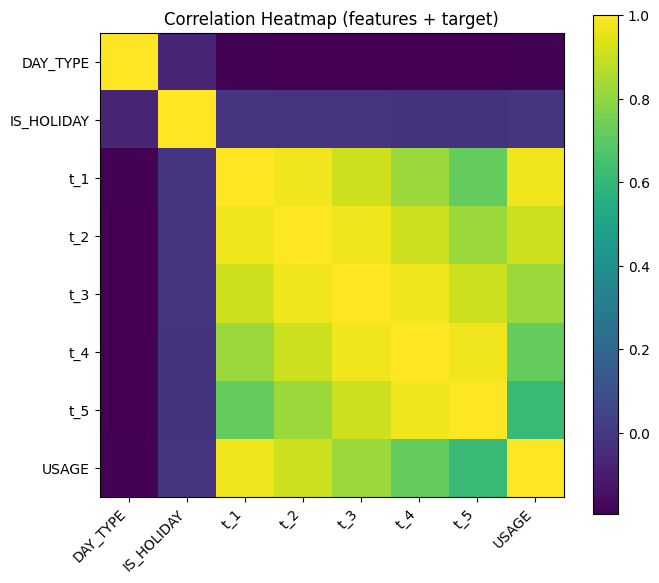

In [10]:
scaler = StandardScaler()          # I'm creating a StandardScaler instance to z-normalize the input features.
X_train_s = scaler.fit_transform(X_train)
X_val_s   = scaler.transform(X_val)
X_test_s  = scaler.transform(X_test)

print(f"Scaled shapes → train:{X_train_s.shape}, val:{X_val_s.shape}, test:{X_test_s.shape}")

# Correlation heatmap
corr = df[feature_cols + [target_col]].corr().values

plt.figure(figsize=(7, 6))
plt.imshow(corr)
plt.title("Correlation Heatmap (features + target)")
plt.xticks(range(len(feature_cols + [target_col])), feature_cols + [target_col], rotation=45, ha="right")
plt.yticks(range(len(feature_cols + [target_col])), feature_cols + [target_col])
plt.colorbar()  # I'm adding a colorbar to interpret correlation strengths.
plt.tight_layout()
plt.show()


# Part 10: Metric helpers

In this, I'm defining helper functions to compute regression metrics both on raw MW scale and on standardized scale (for deep models). This keeps my evaluation logic clean and reusable

In [11]:
def eval_regression_raw(y_true, y_pred, name=""):
    """Eval MAE,RMSE,MAPE and R2 on raw MW."""
    y_true = np.asarray(y_true).reshape(-1)  # I'm ensuring y_true is a flat NumPy array
    y_pred = np.asarray(y_pred).reshape(-1)  # I'm ensuring y_pred is a flat NumPy array

    mae  = mean_absolute_error(y_true, y_pred)
    mse  = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mape = np.mean(np.abs((y_true - y_pred) / (y_true + 1e-8))) * 100.0
    r2   = r2_score(y_true, y_pred)

    print(f"[{name}] MAE={mae:.4f}  RMSE={rmse:.4f}  MAPE={mape:.2f}%  R2={r2:.4f}")
    return mae, rmse, mape, r2


# For deep models: they work on standardized y, we need to map back
y_scaler = StandardScaler()  # I'm creating another scaler specifically for the target series
series_train_s = y_scaler.fit_transform(series_train_raw.reshape(-1, 1)).reshape(-1)
# I'm fitting the target scaler on the training target and storing standardized train series
series_val_s   = y_scaler.transform(series_val_raw.reshape(-1, 1)).reshape(-1)
# I'm transforming validation target using the same scaling learned from train
series_test_s  = y_scaler.transform(series_test_raw.reshape(-1, 1)).reshape(-1)
# I'm transforming test target similarly so everything is on the standardized scale

def eval_regression_robust_scaled(y_true_scaled, y_pred_scaled, name=""):
    """
    y_true_scaled, y_pred_scaled are in standardized scale
    Convert back to original MW using y_scaler and evaluate
    """
    y_true_scaled = np.asarray(y_true_scaled).reshape(-1)
    y_pred_scaled = np.asarray(y_pred_scaled).reshape(-1)

    y_true = y_scaler.inverse_transform(y_true_scaled.reshape(-1, 1)).reshape(-1)
    y_pred = y_scaler.inverse_transform(y_pred_scaled.reshape(-1, 1)).reshape(-1)
    # I'm converting both true and predicted standardized values back to original MW scale.

    mae  = mean_absolute_error(y_true, y_pred)  # Same metrics as before but now on original scale.
    mse  = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mape = np.mean(np.abs((y_true - y_pred) / (y_true + 1e-8))) * 100.0
    r2   = r2_score(y_true, y_pred)

    print(f"[{name}] MAE={mae:.4f}  RMSE={rmse:.4f}  MAPE={mape:.2f}%  R2={r2:.4f}")
    return mae, rmse, mape, r2

# Part 11: Naive baselines (last-value & seasonal 24h)

In this, I'm implementing simple naive forecasting baselines such as a last-value baseline and a 24-hour seasonal baseline. These serve as reference points


In [12]:
df["LAST_VALUE"] = df["USAGE"].shift(1)
# I'm creating a naive "last value" prediction: next hour is approximately equal to previous hour

df["SEASONAL_24"] = df["USAGE"].shift(24)
# I'm creating a 24-hour seasonal naive prediction: next hour approximately equal to same hour yesterday

naive_last_val  = df.loc[mask_val,  "LAST_VALUE"].values
naive_last_test = df.loc[mask_test, "LAST_VALUE"].values
# I'm extracting naive last-value predictions for validation and test windows

naive_seas_val  = df.loc[mask_val,  "SEASONAL_24"].values
naive_seas_test = df.loc[mask_test, "SEASONAL_24"].values
# I'm extracting naive seasonal-24 predictions for validation and test windows

print("\n Naive baselines:")
nl_val_metrics  = eval_regression_raw(series_val_raw,  naive_last_val,  "Val (Naive last)")
nl_test_metrics = eval_regression_raw(series_test_raw, naive_last_test, "Test (Naive last)")
ns_val_metrics  = eval_regression_raw(series_val_raw,  naive_seas_val,  "Val (Naive seasonal-24)")
ns_test_metrics = eval_regression_raw(series_test_raw, naive_seas_test, "Test (Naive seasonal-24)")
# I'm evaluating both naive baselines on val and test sets so I can later compare them with other models


 Naive baselines:
[Val (Naive last)] MAE=149.5128  RMSE=194.4352  MAPE=2.80%  R2=0.9537
[Test (Naive last)] MAE=168.4191  RMSE=212.5512  MAPE=3.01%  R2=0.9550
[Val (Naive seasonal-24)] MAE=377.6109  RMSE=504.1564  MAPE=6.87%  R2=0.6890
[Test (Naive seasonal-24)] MAE=385.3788  RMSE=503.0839  MAPE=6.71%  R2=0.7478


# Part 12: Random Forest baseline (using lag + calendar features)

In this, I'm training a Random Forest regressor on the engineered features to get a strong classical ML baseline and evaluating it on validation and test splits

In [13]:
rf_baseline = RandomForestRegressor(
    n_estimators=300,     # I'm using 300 trees to get a stable ensemble
    max_depth=12,         # limiting depth to prevent overfitting
    min_samples_leaf=2,   # I'm enforcing a minimum number of samples per leaf for regularization
    random_state=42,      # fixing randomness for reproducibility
    n_jobs=-1
)

rf_baseline.fit(X_train_s, y_train)  # fitting the Random Forest on scaled training features

rf_val_pred  = rf_baseline.predict(X_val_s)   # generating predictions on validation data
rf_test_pred = rf_baseline.predict(X_test_s)  # generating predictions on test data

print("\n Random Forest baseline metrics:")
rf_val_metrics  = eval_regression_raw(y_val,  rf_val_pred,  "Val (RF)")
rf_test_metrics = eval_regression_raw(y_test, rf_test_pred, "Test (RF)")


 Random Forest baseline metrics:
[Val (RF)] MAE=74.5673  RMSE=103.4489  MAPE=1.36%  R2=0.9869
[Test (RF)] MAE=78.5774  RMSE=106.1844  MAPE=1.38%  R2=0.9888


# Part 13: Build time-series sequences for deep models

Transforming the standardized target series into supervised learning sequences (sliding windows) that can be consumed by sequence models like LSTMs and BiLSTMs

In [14]:
def make_sequences(values_1d, seq_len=24, horizon=1):
    X, y = [], []
    for i in range(len(values_1d) - seq_len - horizon + 1):
        X.append(values_1d[i : i + seq_len])                   # I'm collecting a window of past seq_len values as inputs.
        y.append(values_1d[i + seq_len + horizon - 1])         # taking the value horizon steps ahead as the target.
    X = np.array(X, dtype="float32")[..., None]   # (N, seq_len, 1)  # converting the list of sequences into a 3D NumPy array with a feature dimension.
    y = np.array(y, dtype="float32")              # (N,)            # converting the target list into a 1D float32 array.
    return X, y

SEQ_LEN = 24   # using a 24-hour lookback window

Xtr_seq, ytr_seq = make_sequences(series_train_s, SEQ_LEN)  # building train sequences from the standardized training series
Xva_seq, yva_seq = make_sequences(series_val_s,   SEQ_LEN)  # building validation sequences
Xte_seq, yte_seq = make_sequences(series_test_s,  SEQ_LEN)  # building test sequences

print("Sequence shapes:")
print("  Train:", Xtr_seq.shape, ytr_seq.shape)
print("  Val:  ", Xva_seq.shape, yva_seq.shape)
print("  Test: ", Xte_seq.shape, yte_seq.shape)

Sequence shapes:
  Train: (129286, 24, 1) (129286,)
  Val:   (4319, 24, 1) (4319,)
  Test:  (9529, 24, 1) (9529,)


# Part 14: Converting sequences to PyTorch tensors + DataLoaders

In this, I'm converting the NumPy sequence arrays into PyTorch tensors and wrapping them into DataLoaders so that training loops can efficiently iterate over mini batches

In [15]:
Xtr_t = torch.tensor(Xtr_seq, dtype=torch.float32)
ytr_t = torch.tensor(ytr_seq, dtype=torch.float32)
Xva_t = torch.tensor(Xva_seq, dtype=torch.float32)
yva_t = torch.tensor(yva_seq, dtype=torch.float32)
Xte_t = torch.tensor(Xte_seq, dtype=torch.float32)
yte_t = torch.tensor(yte_seq, dtype=torch.float32)

train_loader = DataLoader(
    TensorDataset(Xtr_t, ytr_t),  # Bundling train inputs and labels into a TensorDataset
    batch_size=64,                # Using batch size 64 to balance training stability and speed
    shuffle=True,                 # Shuffling training batches to improve learning
    drop_last=False               # Keeping the final smaller batch instead of dropping it
)

val_loader = DataLoader(
    TensorDataset(Xva_t, yva_t),
    batch_size=64,
    shuffle=False,                # I'm not shuffling validation data to have deterministic evaluation
    drop_last=False
)

test_loader = DataLoader(
    TensorDataset(Xte_t, yte_t),
    batch_size=64,
    shuffle=False,                # I'm not shuffling test data either for consistent order
    drop_last=False
)

# Part 15: Training and prediction helper with learning curves

Defining helper functions to train any PyTorch sequence model with early stopping and to generate predictions.
This avoids duplicating training loops for each model.

In [16]:
def train_model(model, train_loader, val_loader,
                epochs=30, lr=1e-3, patience=5, name="model"):
    model = model.to(device)
    criterion = nn.MSELoss()                         # I'm using MSE loss since this is a regression problem.
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)  # I'm using Adam optimizer for adaptive learning rate updates.

    best_state = None        # I'm initializing a placeholder for the best model weights
    best_val_loss = float("inf")  # I'm starting with an infinitely large best validation loss
    best_epoch = -1          # I'm tracking which epoch gave me the best validation performance

    history = {"train_loss": [], "val_loss": []}  # I'm keeping track of loss curves for plotting later

    for epoch in range(1, epochs + 1):
        # ---- train ----
        model.train()        # I'm setting the model in training mode to enable gradients and dropout if any
        train_losses = []    # I'm collecting batch-wise training losses for this epoch
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)  # moving the current batch to the selected device
            optimizer.zero_grad()                  # resetting gradients from the previous step
            yhat = model(xb).squeeze(-1)          # running a forward pass and squeezing the last dim to match target shape.
            loss = criterion(yhat, yb)            # computing MSE loss for this batch
            loss.backward()                       # backpropagating gradients through the model
            optimizer.step()                      # updating model parameters based on gradients
            train_losses.append(loss.item())      # storing the batch loss as a Python float
        train_loss = float(np.mean(train_losses)) # averaging batch losses to get a single train loss for the epoch

        # ---- val ----
        model.eval()           # switching to evaluation mode
        val_losses = []        # collecting validation losses
        with torch.no_grad():  # disabling gradient computation for efficiency during validation
            for xb, yb in val_loader:
                xb, yb = xb.to(device), yb.to(device)
                yhat = model(xb).squeeze(-1)
                loss = criterion(yhat, yb)
                val_losses.append(loss.item())
        val_loss = float(np.mean(val_losses))  # averaging validation batch losses

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)

        print(f"[{name}] Epoch {epoch:03d} | train_loss={train_loss:.6f} | val_loss={val_loss:.6f}")

        # early stopping
        if val_loss < best_val_loss - 1e-6:
            best_val_loss = val_loss
            best_epoch = epoch
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}

        if epoch - best_epoch >= patience:
            print(f"[{name}] Early stopping at epoch {epoch}, best epoch {best_epoch}")
            # stopping training if validation loss hasn't improved for 'patience' epochs.
            break

    if best_state is not None:
        model.load_state_dict(best_state)  # restoring the best-performing model weights at the end

    print(f"[{name}] Best val_loss={best_val_loss:.6f} @ epoch {best_epoch}")
    return model, history  # returning the trained (best) model and its learning curves


def predict_model(model, loader):
    model = model.to(device)
    model.eval()                # putting the model in evaluation mode
    preds = []                  # collecting predictions across all batches
    with torch.no_grad():       # turning off gradient tracking during inference for efficiency
        for xb, _ in loader:
            xb = xb.to(device)
            yhat = model(xb).squeeze(-1)
            preds.append(yhat.cpu().numpy())
    return np.concatenate(preds, axis=0)       # concatenating all batch predictions into a single array


# Part 16: Shared settings for all deep models

In this, I'm defining shared hyperparameters and containers that will be used by all deep learning models (LSTM variants) to keep the configuration consistent and organized

In [17]:
input_dim = 1          # specifying that each time step has one feature (the usage value)
hidden_dim = 64        # choosing the hidden size for LSTM layers
num_layers = 1         # defining the base number of LSTM layers (overridden in stacked models)
dropout = 0.0          # setting dropout to 0.0 by default and can be changed for deeper models
epochs_deep = 30       # setting a common max number of epochs for deep models
patience_deep = 5      # using early stopping patience of 5 epochs
lr_deep = 1e-3         # using a learning rate of 0.001 for Adam

deep_results = []      # initializing a list to store metrics for all deep models
deep_models = {}       # keeping a dictionary of trained deep models by name
deep_histories = {}    # storing learning curves for each deep model

# Part 17: LSTM (single layer)

In this, I'm defining and training a single-layer LSTM model for time-series forecasting, then evaluating it on validation and test sets and plotting its learning curve

[LSTM] Epoch 001 | train_loss=0.038694 | val_loss=0.008039
[LSTM] Epoch 002 | train_loss=0.008720 | val_loss=0.008605
[LSTM] Epoch 003 | train_loss=0.007822 | val_loss=0.006724
[LSTM] Epoch 004 | train_loss=0.007442 | val_loss=0.007634
[LSTM] Epoch 005 | train_loss=0.007081 | val_loss=0.006876
[LSTM] Epoch 006 | train_loss=0.006754 | val_loss=0.006177
[LSTM] Epoch 007 | train_loss=0.006397 | val_loss=0.006412
[LSTM] Epoch 008 | train_loss=0.006070 | val_loss=0.006205
[LSTM] Epoch 009 | train_loss=0.005818 | val_loss=0.006225
[LSTM] Epoch 010 | train_loss=0.005583 | val_loss=0.005670
[LSTM] Epoch 011 | train_loss=0.005413 | val_loss=0.005586
[LSTM] Epoch 012 | train_loss=0.005219 | val_loss=0.005612
[LSTM] Epoch 013 | train_loss=0.005127 | val_loss=0.005195
[LSTM] Epoch 014 | train_loss=0.004984 | val_loss=0.005726
[LSTM] Epoch 015 | train_loss=0.004870 | val_loss=0.005211
[LSTM] Epoch 016 | train_loss=0.004791 | val_loss=0.005476
[LSTM] Epoch 017 | train_loss=0.004701 | val_loss=0.0052

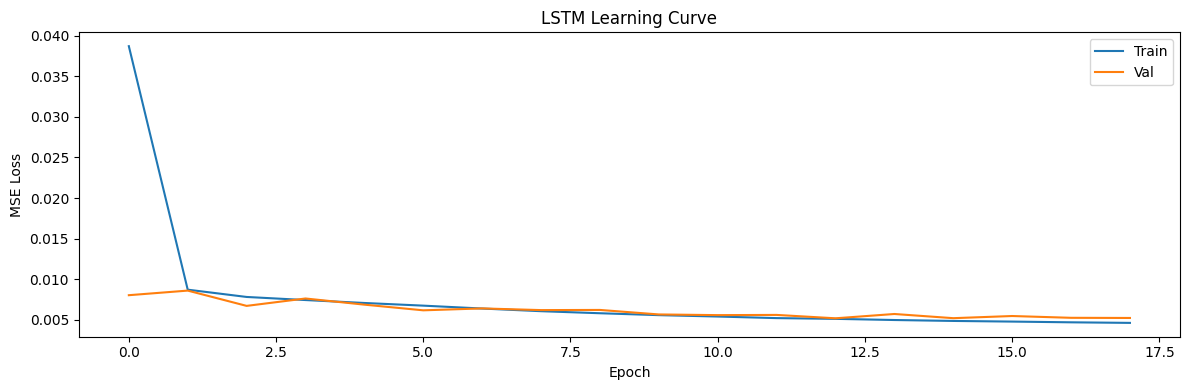

In [18]:
class LSTMModel(nn.Module):
    def __init__(self, input_dim, hidden_dim=64, num_layers=1, dropout=0.0):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=input_dim,           # I'm specifying the input feature dimension per time step
            hidden_size=hidden_dim,         # specifying the hidden state dimension
            num_layers=num_layers,          # using the desired number of stacked LSTM layers
            batch_first=True,               # using (batch, time, feature) input shape
            dropout=dropout if num_layers > 1 else 0.0,  # applying dropout only when there are multiple layers
        )
        self.fc = nn.Linear(hidden_dim, 1)  # mapping the final hidden state to a single scalar output

    def forward(self, x):
        out, _ = self.lstm(x)   # running the input sequence through the LSTM to get outputs per time step
        last = out[:, -1, :]    # taking only the last time step output as the summary of the sequence
        y = self.fc(last)       # passing the summarized representation through a linear layer to predict the next value
        return y

lstm_model = LSTMModel(input_dim=input_dim, hidden_dim=hidden_dim, num_layers=1, dropout=0.0)
# instantiating the single-layer LSTM model

lstm_model, lstm_hist = train_model(
    lstm_model, train_loader, val_loader,
    epochs=epochs_deep, lr=lr_deep, patience=patience_deep, name="LSTM"
)
# training the LSTM model with early stopping using my training helper

lstm_val_pred_s  = predict_model(lstm_model, val_loader)   # generating scaled predictions on the validation set
lstm_test_pred_s = predict_model(lstm_model, test_loader)  # generating scaled predictions on the test set

print("\n LSTM metrics:")
lstm_val_metrics  = eval_regression_robust_scaled(yva_seq, lstm_val_pred_s,  "Val (LSTM)")
lstm_test_metrics = eval_regression_robust_scaled(yte_seq, lstm_test_pred_s, "Test (LSTM)")
# evaluating the LSTM on original MW scale using my helper for scaled outputs

deep_models["LSTM"] = lstm_model        # storing the trained LSTM model for later comparison and analysis
deep_histories["LSTM"] = lstm_hist      # storing the training history for the LSTM
deep_results.append({
    "model": "LSTM",
    "val_MAE":  lstm_val_metrics[0],
    "val_RMSE": lstm_val_metrics[1],
    "val_MAPE": lstm_val_metrics[2],
    "val_R2":   lstm_val_metrics[3],
    "test_MAE":  lstm_test_metrics[0],
    "test_RMSE": lstm_test_metrics[1],
    "test_MAPE": lstm_test_metrics[2],
    "test_R2":   lstm_test_metrics[3],
})
# Here I'm appending the LSTM's validation and test metrics into a results list for later tabular comparison

# Learning curve for LSTM
plt.figure()
plt.plot(lstm_hist["train_loss"], label="Train")  # plotting the training loss across epochs
plt.plot(lstm_hist["val_loss"], label="Val")      # plotting the validation loss to see generalization behavior
plt.title("LSTM Learning Curve")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.legend()
plt.tight_layout()
plt.show()


# Part 18: Stacked LSTM (2 layers)

In this, I'm defining a deeper (2-layer) stacked LSTM model with dropout, training it, evaluating it and plotting its learning curve to see if depth improves performance

[Stacked LSTM] Epoch 001 | train_loss=0.037322 | val_loss=0.008204
[Stacked LSTM] Epoch 002 | train_loss=0.009598 | val_loss=0.007392
[Stacked LSTM] Epoch 003 | train_loss=0.008570 | val_loss=0.007930
[Stacked LSTM] Epoch 004 | train_loss=0.007887 | val_loss=0.006552
[Stacked LSTM] Epoch 005 | train_loss=0.007408 | val_loss=0.007099
[Stacked LSTM] Epoch 006 | train_loss=0.006908 | val_loss=0.006416
[Stacked LSTM] Epoch 007 | train_loss=0.006483 | val_loss=0.006032
[Stacked LSTM] Epoch 008 | train_loss=0.006196 | val_loss=0.005564
[Stacked LSTM] Epoch 009 | train_loss=0.005907 | val_loss=0.005187
[Stacked LSTM] Epoch 010 | train_loss=0.005701 | val_loss=0.006376
[Stacked LSTM] Epoch 011 | train_loss=0.005548 | val_loss=0.005628
[Stacked LSTM] Epoch 012 | train_loss=0.005407 | val_loss=0.005284
[Stacked LSTM] Epoch 013 | train_loss=0.005283 | val_loss=0.005599
[Stacked LSTM] Epoch 014 | train_loss=0.005189 | val_loss=0.005050
[Stacked LSTM] Epoch 015 | train_loss=0.005091 | val_loss=0.00

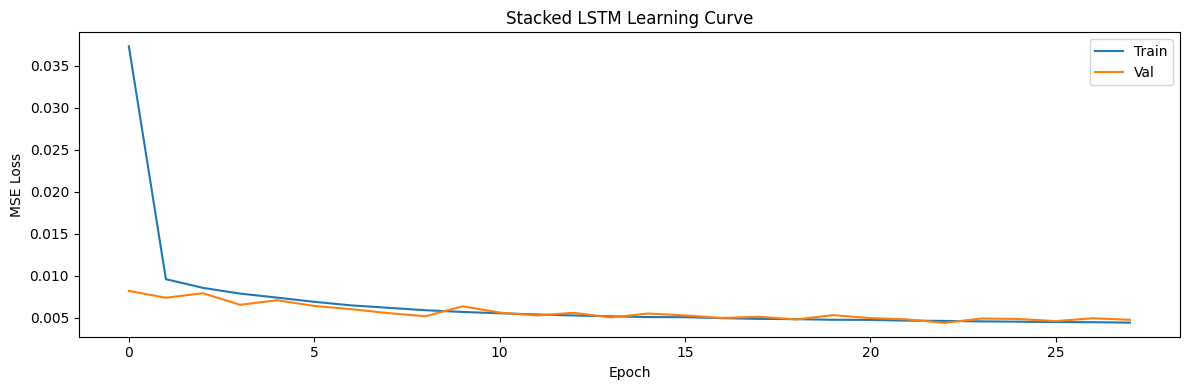

In [19]:
class StackedLSTM(nn.Module):
    def __init__(self, input_dim, hidden_dim=64, num_layers=2, dropout=0.1):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=input_dim,  # using the same input dimension as before
            hidden_size=hidden_dim,
            num_layers=num_layers,  # I'm stacking multiple LSTM layers to increase model capacity
            batch_first=True,
            dropout=dropout,        # applying dropout between stacked LSTM layers for regularization
        )
        self.fc = nn.Linear(hidden_dim, 1)  # mapping the last hidden state to a single output

    def forward(self, x):
        out, _ = self.lstm(x)      # running the stacked LSTM over the input sequence
        last = out[:, -1, :]       # taking the final time step output as sequence representation
        return self.fc(last)       # predicting the next value using a linear layer

stacked_lstm_model = StackedLSTM(input_dim=input_dim, hidden_dim=hidden_dim, num_layers=2, dropout=0.1)
# instantiating the stacked LSTM with two layers and some dropout

stacked_lstm_model, stl_hist = train_model(
    stacked_lstm_model, train_loader, val_loader,
    epochs=epochs_deep, lr=lr_deep, patience=patience_deep, name="Stacked LSTM"
)
# training the stacked LSTM with the same training helper and hyperparameters

stl_val_pred_s  = predict_model(stacked_lstm_model, val_loader)   # getting validation predictions from the stacked LSTM
stl_test_pred_s = predict_model(stacked_lstm_model, test_loader)  # getting test predictions from the stacked LSTM

print("\n Stacked LSTM metrics:")
stl_val_metrics  = eval_regression_robust_scaled(yva_seq, stl_val_pred_s,  "Val (Stacked LSTM)")
stl_test_metrics = eval_regression_robust_scaled(yte_seq, stl_test_pred_s, "Test (Stacked LSTM)")
# evaluating the stacked LSTM in MW space using my helper.

deep_models["StackedLSTM"] = stacked_lstm_model   # storing the stacked LSTM model for later comparison
deep_histories["StackedLSTM"] = stl_hist          # storing its learning curves
deep_results.append({
    "model": "StackedLSTM",
    "val_MAE":  stl_val_metrics[0],
    "val_RMSE": stl_val_metrics[1],
    "val_MAPE": stl_val_metrics[2],
    "val_R2":   stl_val_metrics[3],
    "test_MAE":  stl_test_metrics[0],
    "test_RMSE": stl_test_metrics[1],
    "test_MAPE": stl_test_metrics[2],
    "test_R2":   stl_test_metrics[3],
})
# recording all stacked LSTM metrics in the results list

plt.figure()
plt.plot(stl_hist["train_loss"], label="Train")  # plotting stacked LSTM's training loss
plt.plot(stl_hist["val_loss"], label="Val")      # plotting stacked LSTM's validation loss
plt.title("Stacked LSTM Learning Curve")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.legend()
plt.tight_layout()
plt.show()

# Part 19: Bidirectional LSTM

In this, I'm defining a bidirectional LSTM, which processes sequences in both forward and backward directions, then training and evaluating it to see if bidirectionality helps on this forecasting task

[BiLSTM] Epoch 001 | train_loss=0.033312 | val_loss=0.009041
[BiLSTM] Epoch 002 | train_loss=0.009022 | val_loss=0.008890
[BiLSTM] Epoch 003 | train_loss=0.007959 | val_loss=0.007801
[BiLSTM] Epoch 004 | train_loss=0.007450 | val_loss=0.007259
[BiLSTM] Epoch 005 | train_loss=0.007019 | val_loss=0.006884
[BiLSTM] Epoch 006 | train_loss=0.006726 | val_loss=0.006252
[BiLSTM] Epoch 007 | train_loss=0.006466 | val_loss=0.007399
[BiLSTM] Epoch 008 | train_loss=0.006184 | val_loss=0.005919
[BiLSTM] Epoch 009 | train_loss=0.005856 | val_loss=0.005493
[BiLSTM] Epoch 010 | train_loss=0.005639 | val_loss=0.005759
[BiLSTM] Epoch 011 | train_loss=0.005452 | val_loss=0.006051
[BiLSTM] Epoch 012 | train_loss=0.005329 | val_loss=0.005402
[BiLSTM] Epoch 013 | train_loss=0.005150 | val_loss=0.005727
[BiLSTM] Epoch 014 | train_loss=0.005033 | val_loss=0.005204
[BiLSTM] Epoch 015 | train_loss=0.004921 | val_loss=0.005171
[BiLSTM] Epoch 016 | train_loss=0.004842 | val_loss=0.005703
[BiLSTM] Epoch 017 | tra

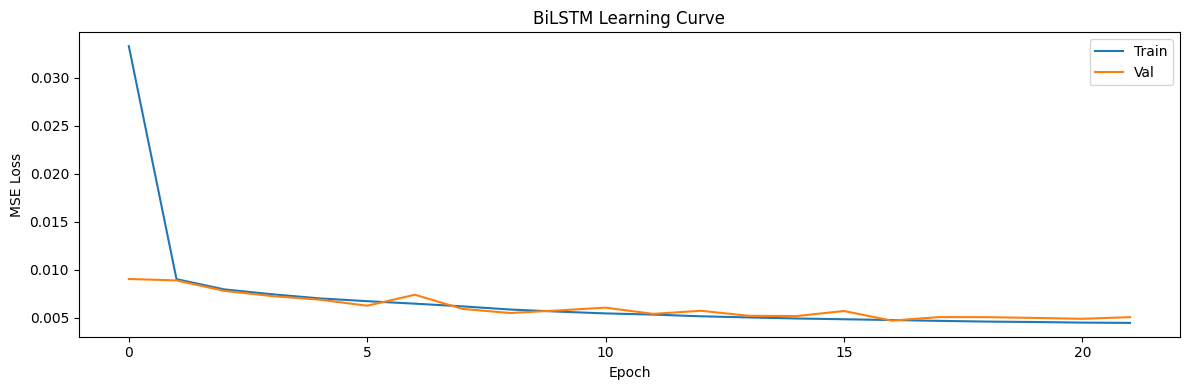

In [20]:
class BiLSTM(nn.Module):
    def __init__(self, input_dim, hidden_dim=64, num_layers=1, dropout=0.0):
        super().__init__()
        self.bilstm = nn.LSTM(
            input_size=input_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=True,                   # enabling bidirectional processing to capture patterns from both directions in the sequence
            dropout=dropout if num_layers > 1 else 0.0,
        )
        self.fc = nn.Linear(hidden_dim * 2, 1)    # using hidden_dim*2 because BiLSTM concatenates forward and backward hidden states

    def forward(self, x):
        out, _ = self.bilstm(x)    # running the sequence through the bidirectional LSTM
        last = out[:, -1, :]       # taking the last time step which contains concatenated forward and backward information
        return self.fc(last)       # mapping that representation to a single scalar prediction

bilstm_model = BiLSTM(input_dim=input_dim, hidden_dim=hidden_dim, num_layers=1, dropout=0.0)
# instantiating the BiLSTM model with the chosen hyperparameters

bilstm_model, bilstm_hist = train_model(
    bilstm_model, train_loader, val_loader,
    epochs=epochs_deep, lr=lr_deep, patience=patience_deep, name="BiLSTM"
)
# training the BiLSTM model using the training helper

bilstm_val_pred_s  = predict_model(bilstm_model, val_loader)   # getting validation predictions from the BiLSTM
bilstm_test_pred_s = predict_model(bilstm_model, test_loader)  # getting test predictions from the BiLSTM

print("\n BiLSTM metrics:")
bilstm_val_metrics  = eval_regression_robust_scaled(yva_seq, bilstm_val_pred_s,  "Val (BiLSTM)")
bilstm_test_metrics = eval_regression_robust_scaled(yte_seq, bilstm_test_pred_s, "Test (BiLSTM)")
# evaluating the BiLSTM on original scale to compare fairly with other models

deep_models["BiLSTM"] = bilstm_model          # storing the trained BiLSTM model
deep_histories["BiLSTM"] = bilstm_hist        # storing its training history
deep_results.append({
    "model": "BiLSTM",
    "val_MAE":  bilstm_val_metrics[0],
    "val_RMSE": bilstm_val_metrics[1],
    "val_MAPE": bilstm_val_metrics[2],
    "val_R2":   bilstm_val_metrics[3],
    "test_MAE":  bilstm_test_metrics[0],
    "test_RMSE": bilstm_test_metrics[1],
    "test_MAPE": bilstm_test_metrics[2],
    "test_R2":   bilstm_test_metrics[3],
})
# adding BiLSTM metrics into the shared results table

plt.figure()
plt.plot(bilstm_hist["train_loss"], label="Train")  # plotting BiLSTM training loss over epochs
plt.plot(bilstm_hist["val_loss"], label="Val")      # plotting BiLSTM validation loss
plt.title("BiLSTM Learning Curve")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.legend()
plt.tight_layout()
plt.show()


# Part 20: Combined results table

Consolidating all baseline and deep model metrics into a single DataFrame, sorting them by validation RMSE and printing them so I can easily compare which model performs best

In [21]:
baseline_rows = [
    {
        "model": "NaiveLast",
        "val_MAE":  nl_val_metrics[0],
        "val_RMSE": nl_val_metrics[1],
        "val_MAPE": nl_val_metrics[2],
        "val_R2":   nl_val_metrics[3],
        "test_MAE":  nl_test_metrics[0],
        "test_RMSE": nl_test_metrics[1],
        "test_MAPE": nl_test_metrics[2],
        "test_R2":   nl_test_metrics[3],
    },
    {
        "model": "NaiveSeasonal24",
        "val_MAE":  ns_val_metrics[0],
        "val_RMSE": ns_val_metrics[1],
        "val_MAPE": ns_val_metrics[2],
        "val_R2":   ns_val_metrics[3],
        "test_MAE":  ns_test_metrics[0],
        "test_RMSE": ns_test_metrics[1],
        "test_MAPE": ns_test_metrics[2],
        "test_R2":   ns_test_metrics[3],
    },
    {
        "model": "RandomForest",
        "val_MAE":  rf_val_metrics[0],
        "val_RMSE": rf_val_metrics[1],
        "val_MAPE": rf_val_metrics[2],
        "val_R2":   rf_val_metrics[3],
        "test_MAE":  rf_test_metrics[0],
        "test_RMSE": rf_test_metrics[1],
        "test_MAPE": rf_test_metrics[2],
        "test_R2":   rf_test_metrics[3],
    },
]

results_df = pd.DataFrame(baseline_rows + deep_results)

results_df = results_df.sort_values("val_RMSE").reset_index(drop=True)

print("\n====================")
print("Model comparison")
print("====================")
print(results_df)


Model comparison
             model     val_MAE    val_RMSE  val_MAPE    val_R2    test_MAE  \
0      StackedLSTM   49.288052   64.882360  0.909167  0.994870   51.923252   
1           BiLSTM   51.005833   67.071506  0.938512  0.994518   53.933399   
2             LSTM   53.793282   70.498113  0.992095  0.993944   55.574425   
3     RandomForest   74.567336  103.448875  1.364116  0.986904   78.577400   
4        NaiveLast  149.512779  194.435169  2.800309  0.953736  168.419135   
5  NaiveSeasonal24  377.610868  504.156424  6.865141  0.688955  385.378834   

    test_RMSE  test_MAPE   test_R2  
0   68.138491   0.913940  0.995377  
1   70.862574   0.949601  0.995000  
2   73.314551   0.982732  0.994648  
3  106.184425   1.378180  0.988766  
4  212.551151   3.008492  0.954987  
5  503.083880   6.709930  0.747833  


# Part 21: Residual and error analysis for best deep model

In this final part, I'm selecting the best deep model based on validation RMSE, computing its predictions on the test set in original MW scale and performing detailed residual analysis to understand where and when it makes bigger errors


 Best deep model based on val_RMSE: StackedLSTM


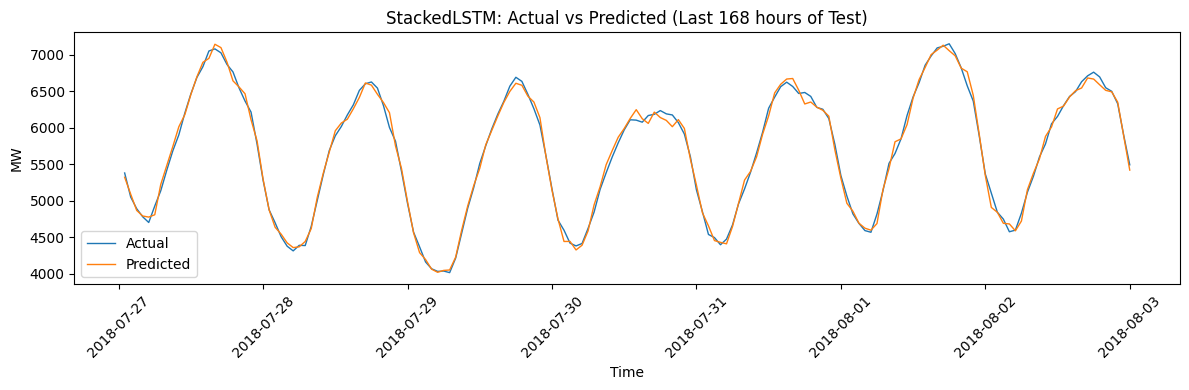

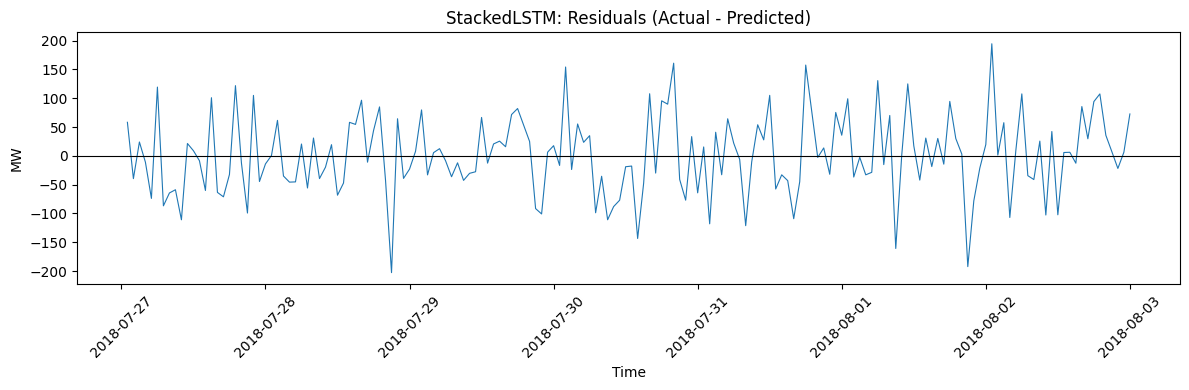

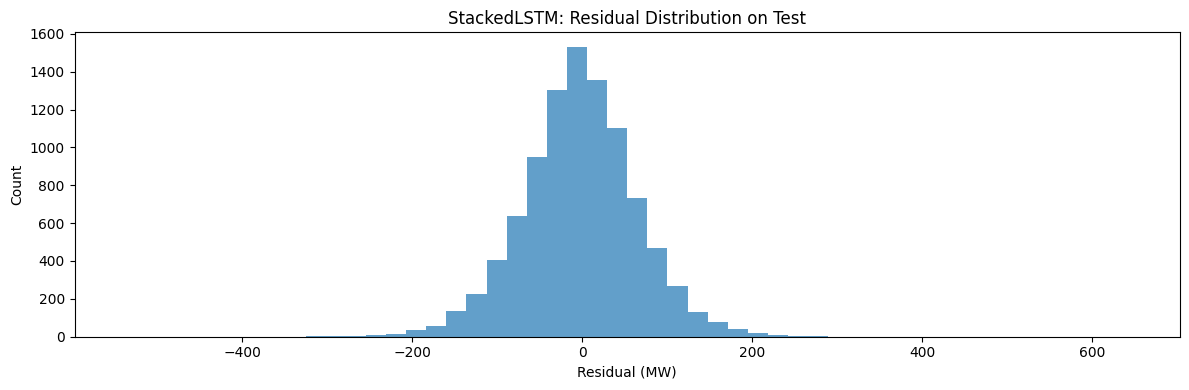

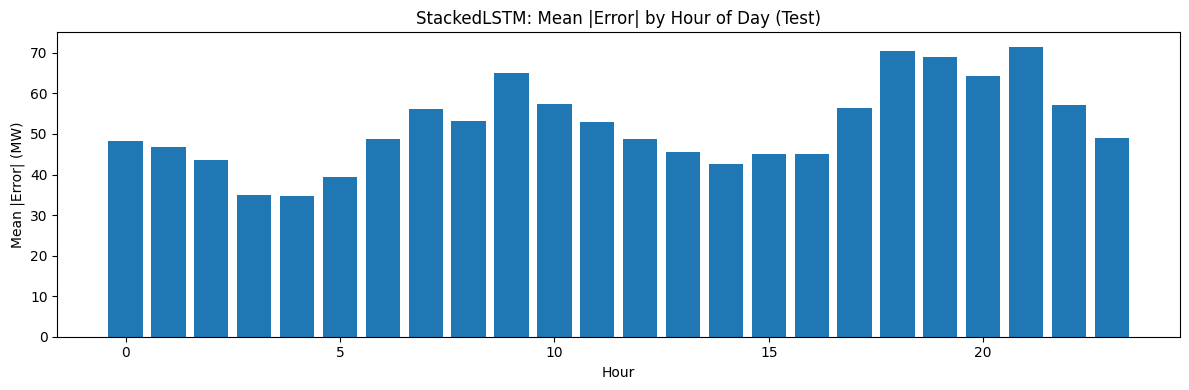

In [22]:
best_row = results_df[results_df["model"].isin(deep_models.keys())].sort_values("val_RMSE").iloc[0]
# filtering the results to only deep models, sorting by val_RMSE and picking the best one

best_model_name = best_row["model"]
print(f"\n Best deep model based on val_RMSE: {best_model_name}")

best_model = deep_models[best_model_name]              # retrieving the best deep model object from my dictionary
best_test_pred_s = predict_model(best_model, test_loader)  # getting its standardized predictions on the test loader

# Convert to original MW
y_true_test = y_scaler.inverse_transform(yte_seq.reshape(-1, 1)).reshape(-1)

y_pred_test = y_scaler.inverse_transform(best_test_pred_s.reshape(-1, 1)).reshape(-1)


residuals = y_true_test - y_pred_test
# computing residuals (actual - predicted) to analyze the model's error patterns

abs_residuals = np.abs(residuals)
# also computing absolute residuals to study the magnitude of errors without sign

# Actual vs Predicted over last week of test
hours_window = 7 * 24
if len(y_true_test) < hours_window:
    hours_window = len(y_true_test)
# defining a window of one week to zoom into recent predictions

y_true_win = y_true_test[-hours_window:]  # taking the last 'hours_window' actual values
y_pred_win = y_pred_test[-hours_window:]  # taking the corresponding predicted values


test_indices = np.where(mask_test.values)[0]
# getting indices of the DataFrame rows that belong to the test period


target_pos_in_test = np.arange(SEQ_LEN, SEQ_LEN + len(y_true_test))
# computing the positions of the target timestamps relative to the test series start and offset by the sequence length

target_pos_in_test = target_pos_in_test[target_pos_in_test < len(test_indices)]
# ensuring these positions do not exceed the number of test indices

df_indices_for_y = test_indices[target_pos_in_test]
# mapping the sequence-based positions back to original DataFrame indices

time_for_y = df["DATE_TIME"].iloc[df_indices_for_y].values[-hours_window:]
# extracting the corresponding timestamps for the last 'hours_window' targets

plt.figure(figsize=(12, 4))
plt.plot(time_for_y, y_true_win, label="Actual", linewidth=1.0)     # plotting actual MW values
plt.plot(time_for_y, y_pred_win, label="Predicted", linewidth=1.0)  # plotting predicted MW values from the best model
plt.title(f"{best_model_name}: Actual vs Predicted (Last {hours_window} hours of Test)")
plt.xlabel("Time")
plt.ylabel("MW")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Residual time series
plt.figure(figsize=(12, 4))
plt.plot(time_for_y, residuals[-hours_window:], linewidth=0.8)
# plotting residuals over time to see periods of under and over-prediction

plt.axhline(0, color="black", linewidth=0.8)

plt.title(f"{best_model_name}: Residuals (Actual - Predicted)")
plt.xlabel("Time")
plt.ylabel("MW")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Residual histogram
plt.figure()
plt.hist(residuals, bins=50, alpha=0.7)
# plotting a histogram of residuals to see their distribution

plt.title(f"{best_model_name}: Residual Distribution on Test")
plt.xlabel("Residual (MW)")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

# Average absolute error by hour of day
hours_all = df["DATE_TIME"].iloc[df_indices_for_y].dt.hour.values[:len(abs_residuals)]

err_by_hour = pd.DataFrame({"hour": hours_all, "abs_error": abs_residuals})
# building a small DataFrame mapping hour-of-day to absolute error

hour_stats = err_by_hour.groupby("hour")["abs_error"].mean()
# computing mean absolute error per hour to see when the model struggles more

plt.figure()
plt.bar(hour_stats.index, hour_stats.values)
# plotting mean |error| by hour of day to identify hours with higher prediction difficulty

plt.title(f"{best_model_name}: Mean |Error| by Hour of Day (Test)")
plt.xlabel("Hour")
plt.ylabel("Mean |Error| (MW)")
plt.tight_layout()
plt.show()